# Walkthrough: PPO's clip range, taken apart

This notebook is the hands-on companion to [GUIDE.md](GUIDE.md). It does three things:

1. draws the clipped surrogate so you can *see* the dead zones,
2. trains two small PPO agents live with opposite clip asymmetries and watches their entropy,
3. loads the real sweep results.

Run it top to bottom: `uv run jupyter execute walkthrough.ipynb` or open it in Jupyter.
The two live training cells take about a minute total on a laptop CPU.

## 1. The objective, and where its gradient dies

PPO's per-sample loss with a split clip range:

$$L_t(\theta) = \min\!\big(r_t A_t,\ \mathrm{clip}(r_t,\, 1-\epsilon_{low},\, 1+\epsilon_{high})\, A_t\big), \qquad r_t = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{old}}(a_t \mid s_t)}$$

Plot $L$ as a function of the ratio for a positive-advantage and a negative-advantage sample.
Where the curve is flat, the gradient is zero — the sample has been silenced. The two flat
shelves are controlled by **different** bounds, and that is the entire premise of this repo.

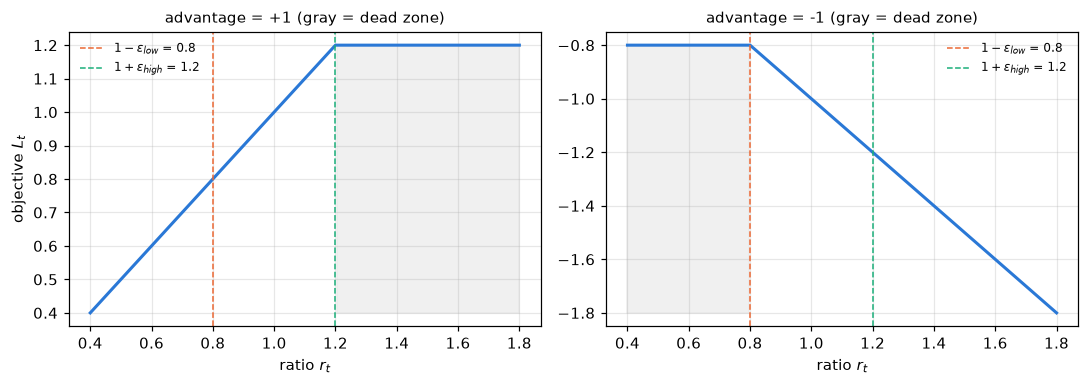

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from ppo import ppo_policy_loss

CLIP_LOW, CLIP_HIGH = 0.2, 0.2
ratios = np.linspace(0.4, 1.8, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), dpi=110)
for ax, adv in zip(axes, [+1.0, -1.0]):
    # ppo_policy_loss returns the (negated) loss; flip sign to plot the objective
    L = [-ppo_policy_loss(torch.tensor([r]), torch.tensor([adv]),
                          CLIP_LOW, CLIP_HIGH).item() for r in ratios]
    ax.plot(ratios, L, color="#2a78d6", linewidth=2)
    ax.axvline(1 - CLIP_LOW, color="#eb6834", linewidth=1, linestyle="--",
               label=f"$1-\\epsilon_{{low}}$ = {1-CLIP_LOW}")
    ax.axvline(1 + CLIP_HIGH, color="#1baf7a", linewidth=1, linestyle="--",
               label=f"$1+\\epsilon_{{high}}$ = {1+CLIP_HIGH}")
    dead = ratios > 1 + CLIP_HIGH if adv > 0 else ratios < 1 - CLIP_LOW
    ax.fill_between(ratios, min(L), max(L), where=dead, color="#e6e6e6", alpha=0.6)
    ax.set_title(f"advantage = {adv:+.0f} (gray = dead zone)", fontsize=10)
    ax.set_xlabel("ratio $r_t$")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("objective $L_t$")
plt.tight_layout()
plt.show()

Read the two panels together, keeping one fact in mind: an action with old probability
$p$ has a ratio ceiling of $1/p$, so **both bounds bind almost exclusively on rare actions**
(a dominant action's ratio barely moves; a rare action's ratio flies).

- **Left ($A>0$):** the objective flattens above $1+\epsilon_{high}$ — the policy must stop
  boosting. The actions that hit this bound are rare-but-good ones being pulled up.
  A tight $\epsilon_{high}$ freezes them early → the tail never regrows → entropy falls.
  Loosening it (DAPO's "clip-higher") lets rare winners climb → entropy rises.
- **Right ($A<0$):** it flattens below $1-\epsilon_{low}$ — the policy must stop suppressing.
  A tight $\epsilon_{low}$ halts the drain of tail mass early → entropy is preserved.

Park et al. ([2509.26114](https://arxiv.org/abs/2509.26114)) measured exactly this in LLM
fine-tuning. The question is whether it survives the trip from 100k actions to 6.

## 2. Two live runs, opposite asymmetries

CartPole, 80k steps, `ent_coef=0`, same seed, the two opposite corners of the grid. Both
bounds bind on *rare* actions (a rare action's ratio has enormous headroom; a dominant
action's ratio is capped at $1/p$), so: a **tight** `clip_low` stops the suppression of
rare actions early (entropy-preserving), and a **loose** `clip_high` lets rare good
actions climb (entropy-restoring). Max-entropy corner: `(0.05, 0.5)`. Min-entropy corner:
`(0.3, 0.1)`. CartPole's action space is only $|A|=2$ (max entropy $\ln 2 \approx 0.69$)
and it's one seed, so treat this as a demo of the harness, not evidence — the real
experiment is the MinAtar grid.

In [2]:
from ppo import Config, train
import json

runs = {}
for name, cl, ch in [("max-entropy corner (cl=0.05, ch=0.5)", 0.05, 0.5),
                     ("min-entropy corner (cl=0.3, ch=0.1)", 0.3, 0.1)]:
    cfg = Config(env_id="CartPole-v1", total_steps=80_000, num_envs=8,
                 epochs=8, lr=1e-3, ent_coef=0.0,
                 clip_low=cl, clip_high=ch, seed=3,
                 out_dir=f"runs/notebook/cl{cl}_ch{ch}")
    out = train(cfg)
    runs[name] = [json.loads(line) for line in (out / "metrics.jsonl").read_text().splitlines()]
    print(f"{name}: final return {runs[name][-1]['episodic_return']:.0f}")

max-entropy corner (cl=0.05, ch=0.5): final return 429


min-entropy corner (cl=0.3, ch=0.1): final return 421


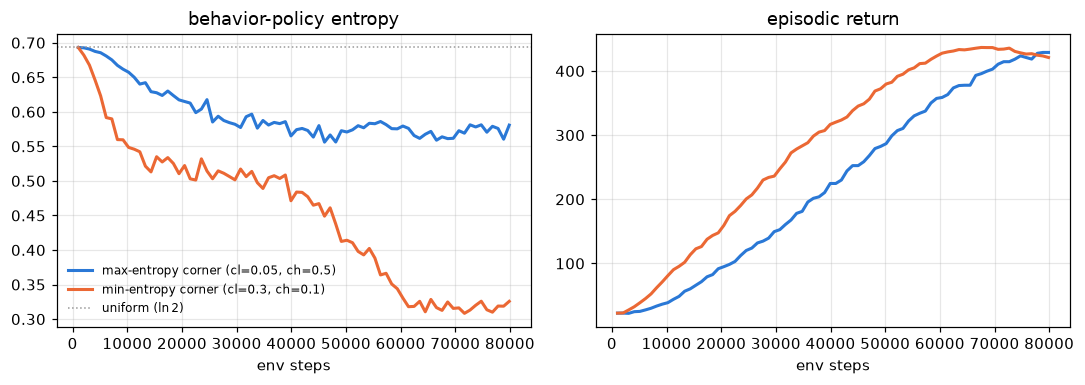

In [3]:
fig, (ax_e, ax_r) = plt.subplots(1, 2, figsize=(10, 3.6), dpi=110)
for (name, rows), color in zip(runs.items(), ["#2a78d6", "#eb6834"]):
    steps = [r["global_step"] for r in rows]
    ax_e.plot(steps, [r["entropy"] for r in rows], color=color, linewidth=2, label=name)
    ax_r.plot(steps, [r["episodic_return"] or 0 for r in rows], color=color, linewidth=2)
ax_e.axhline(np.log(2), color="#999", linewidth=1, linestyle=":", label="uniform ($\\ln 2$)")
ax_e.set_title("behavior-policy entropy"); ax_r.set_title("episodic return")
for ax in (ax_e, ax_r):
    ax.set_xlabel("env steps"); ax.grid(alpha=0.3)
ax_e.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 3. The real experiment

The MinAtar grid (`ppo/sweep.py`): 4 values of `clip_low` x 4 of `clip_high` x 5 seeds x
`ent_coef=0` x 3M steps, on breakout and asterix, in the probed regime where the clip
actually engages (~2% of samples per side — with CleanRL defaults it engages on <0.3%
and the grid would measure nothing). Headline: the entropy mechanism transfers with a
monotone dose-response on both axes of both games, `clip_low` is ~3x the stronger dial,
and the *performance* effect flips between games (high entropy wins breakout, loses
asterix). Full discussion in the README.

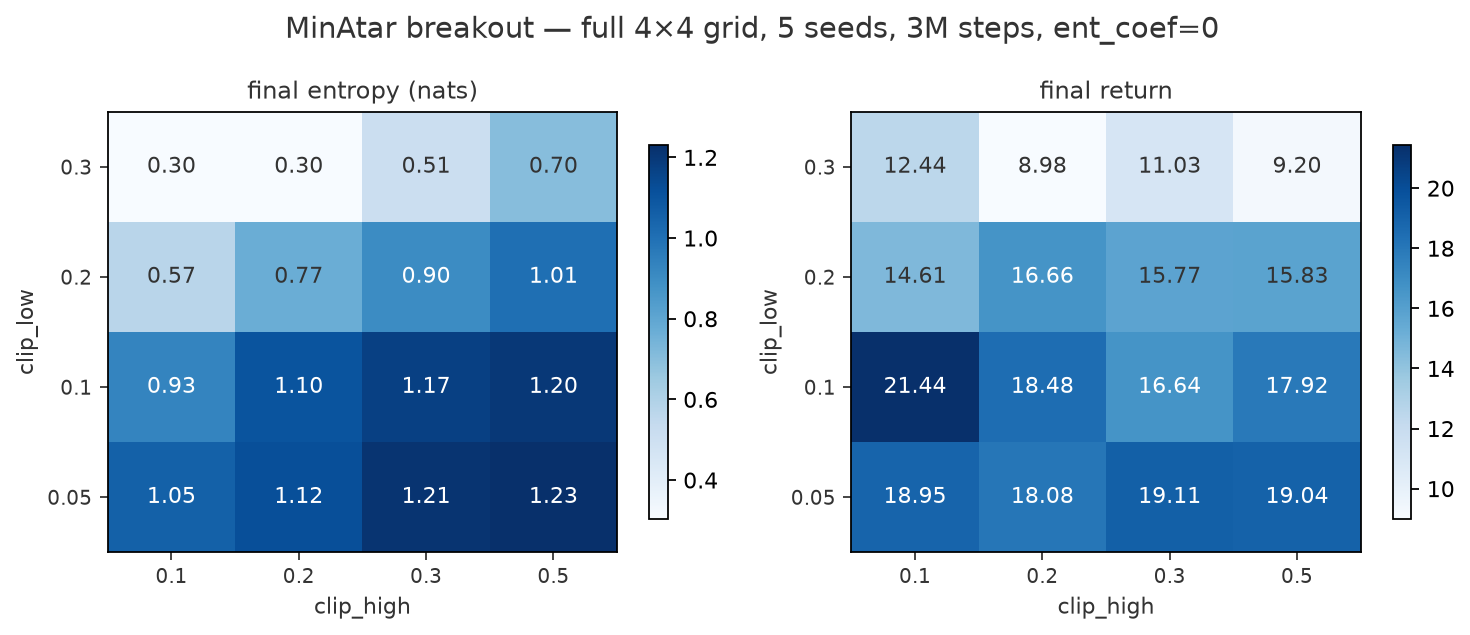

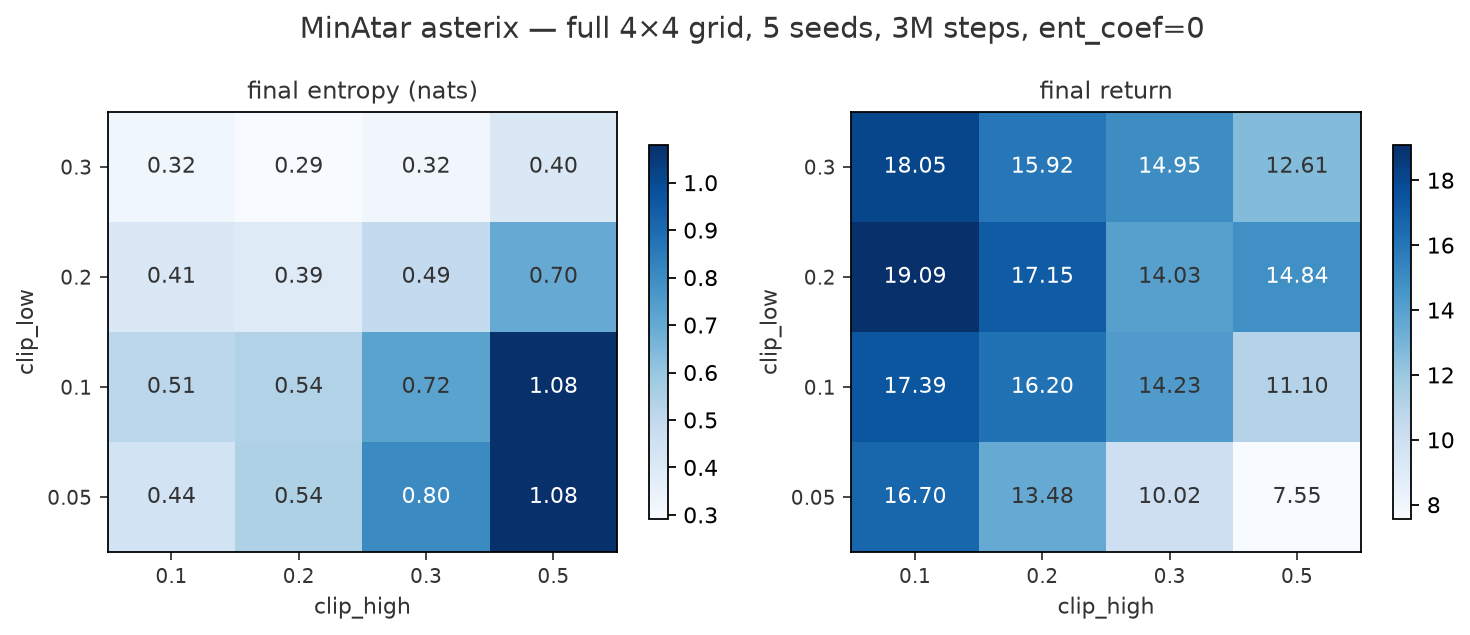

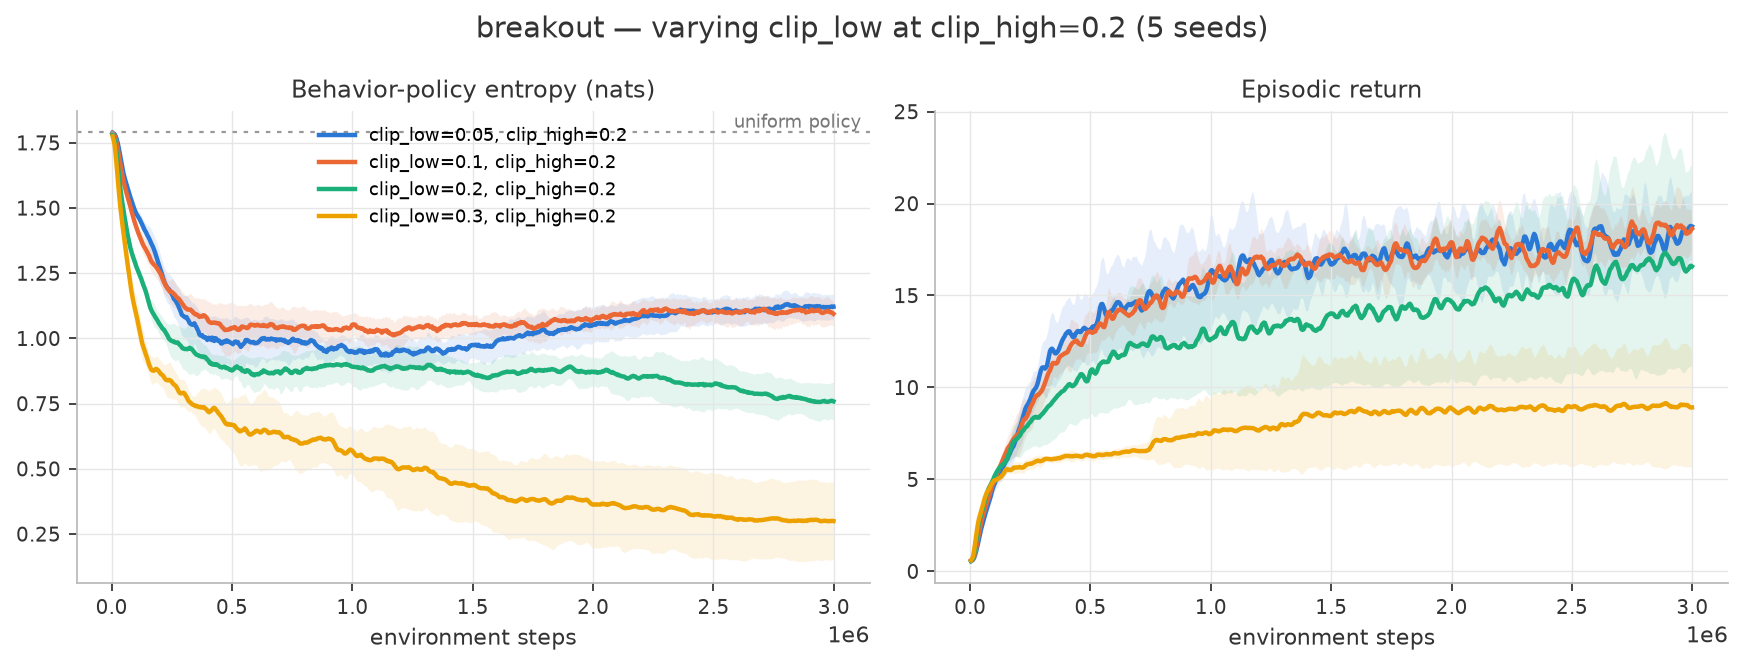

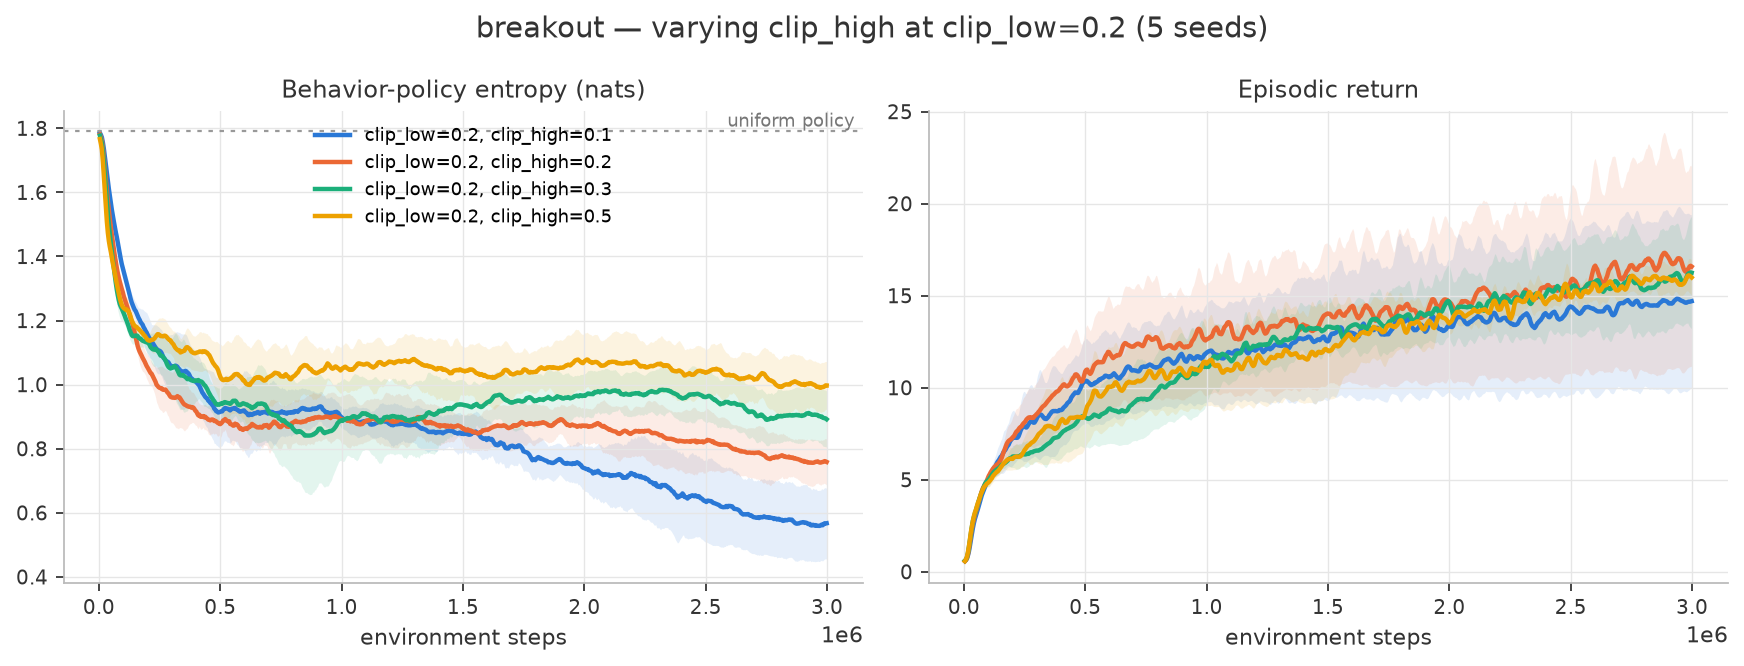

In [4]:
import pathlib
from IPython.display import Image, display

wanted = ["breakout_heatmap.png", "asterix_heatmap.png",
          "breakout_varylow_trajectories.png", "breakout_varyhigh_trajectories.png"]
found = [f for f in wanted if (pathlib.Path("figures") / f).exists()]
if found:
    for f in found:
        display(Image(f"figures/{f}"))
else:
    print("No figures yet - run:")
    print("  uv run python -m ppo.sweep --env minatar/breakout --out runs/breakout-grid")
    print("  uv run python -m ppo.plot --runs runs/breakout-grid --out figures --prefix breakout")

## 4. Where to go from here

- `GUIDE.md` has the full derivation and the design-decision log.
- `tests/test_clip.py` is the dead-zone table as executable assertions — read it next to §1.
- To extend the experiment to a bigger action space (the load-bearing arm, per DPPO's
  vocabulary-size hypothesis): MinAtar is $|A|=6$; full Atari is 18; a combinatorial
  gridworld can push $|A|$ into the hundreds. The harness only needs an env with the
  `SyncVecEnv` step signature.